In [8]:
from ultralytics import YOLO


In [9]:
model = YOLO('yolov8n.pt')

In [10]:
model.train(
    data='parking-lot-1/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='occupancy_detector_v2'   
)

New https://pypi.org/project/ultralytics/8.4.111 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.109  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (Quadro P620, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=parking-lot-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000292E6A7E3C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [11]:
from ultralytics import YOLO

model = YOLO("runs/detect/occupancy_detector_v2/weights/best.pt")

metrics = model.val(data="parking-lot-1/data.yaml")


print("="*50)
print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP75    : {metrics.box.map75:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall   : {metrics.box.mr:.4f}")
print("="*50)

print("\nPer-class mAP50-95:")
for i, ap in enumerate(metrics.box.maps):
    print(f"  Class {i}: {ap:.4f}")

Ultralytics 8.4.109  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (Quadro P620, 4096MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 465.1185.0 MB/s, size: 91.1 KB)
val: Scanning D:\Smart Parking system\parking-lot-1\valid\labels.cache... 280 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 280/280  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 4155, len(boxes) = 6474. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.8it/s 6.4s0.3s
                   all        280       6474      0.907      0.881      0.944      0.836
                     0        101        740      0.871      0.838      0.934      0.836
                     1         93


image 1/1 C:\Users\PC\Downloads\images.jpg: 576x640 6 3s, 8 4s, 35.7ms
Speed: 4.7ms preprocess, 35.7ms inference, 2.1ms postprocess per image at shape (1, 3, 576, 640)
Results saved to D:\Smart Parking system\runs\detect\predict-21


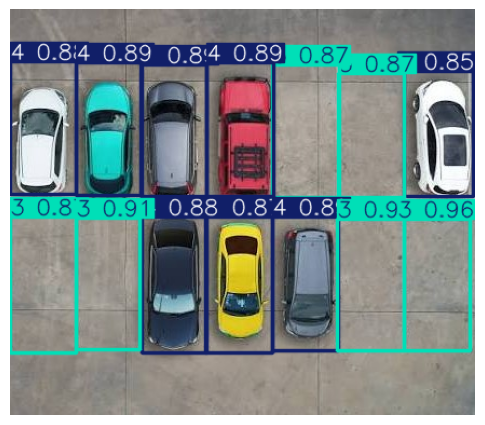

In [3]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt")

results = model.predict(source=r"C:\Users\PC\Downloads\images.jpg", conf=0.25, save=True)

result_image = results[0].plot()
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(result_image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\PC\Downloads\WhatsApp Imagee 2026-07-30 at 2.20.17 AM.jpeg: 544x640 10 3s, 5 4s, 39.0ms
Speed: 5.0ms preprocess, 39.0ms inference, 2.0ms postprocess per image at shape (1, 3, 544, 640)
Results saved to D:\Smart Parking system\runs\detect\predict-24


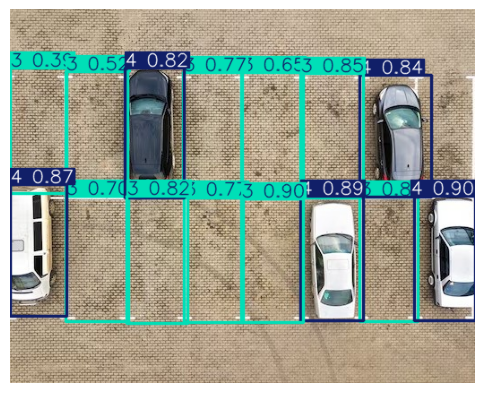

In [6]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt")

results = model.predict(source=r"C:\Users\PC\Downloads\WhatsApp Imagee 2026-07-30 at 2.20.17 AM.jpeg", conf=0.25, save=True)

result_image = results[0].plot()
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(result_image_rgb)
plt.axis('off')
plt.show()


image 1/1 C:\Users\PC\Downloads\WhatsApp Image 2026-07-30 at 2.21.25 AM.jpeg: 448x640 7 3s, 8 4s, 95.2ms
Speed: 4.7ms preprocess, 95.2ms inference, 3.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to D:\Smart Parking system\runs\detect\predict-26


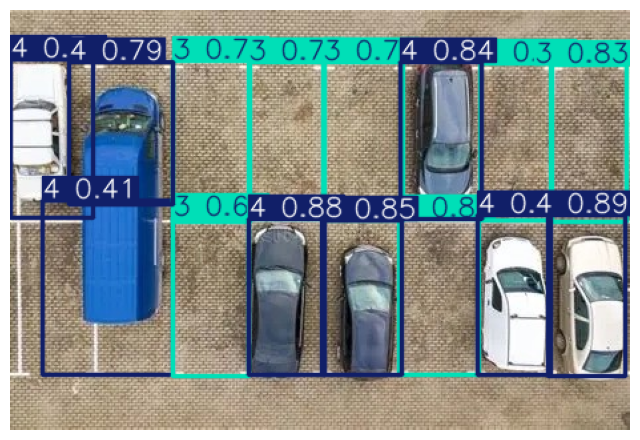

In [8]:
%matplotlib inline

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt")

results = model.predict(source=r"C:\Users\PC\Downloads\WhatsApp Image 2026-07-30 at 2.21.25 AM.jpeg", conf=0.25, save=True)

result_image = results[0].plot()
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(result_image_rgb)
plt.axis('off')
plt.show()

In [2]:
from ultralytics import YOLO
print(YOLO(r"D:\Smart Parking system\runs\detect\occupancy_detector_v2\weights\best.pt").names)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: 'object'}
